# Phase de training
#### Data Augmentation + Transfer Learning avec MobileNetV2

##### 1. Importation 
+ TensorFlow est la bibliothèque principale utilisée pour le Deep Learning et l’intelligence artificielle.Elle permet de : créer des réseaux de neurones,entraîner des modèles,manipuler les données, effectuer les calculs mathématiques.

+ Keras est l’API de haut niveau de TensorFlow.Elle permet de : créer les couches du réseau,compiler le modèle,lancer l’entraînement,sauvegarder le modèle.

+ Matplotlib est une bibliothèque utilisée pour afficher des graphiques.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

##### 2. Chargement du dataset
Cette cellule définit le chemin du dossier contenant les images du dataset.

In [2]:
dataset_path = "../dataset"

##### 3. Training dataset
Cette cellule charge automatiquement les images du dataset pour créer les données d’entraînement.
+ image_dataset_from_directory() : Cette fonction :lit les images depuis les dossiers,crée automatiquement les labels,prépare les données pour TensorFlow.
+ validation_split=0.2 : Cette ligne réserve : 20% des images pour la validation, 80% pour l’entraînement.
+ subset="training" : Charger uniq les donnees d'entrainement.
+ image_size=(224,224) :  Toutes les images seront redimensionnées à : 224 × 224 pixels parce que MobileNetV2 utilise cette taille d’entrée.
+ batch_size=32 :Les images seront envoyées au modèle par groupes de 32.Un batch permet : d’accélérer l’entraînement et d’optimiser la mémoire.

In [3]:
train_dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 2525 files belonging to 6 classes.
Using 2020 files for training.


##### 4. Validation or testing dataset
Cette cellule cree le dataset de validation

In [4]:
val_dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 2525 files belonging to 6 classes.
Using 505 files for validation.


##### 5. Classes
TensorFlow récupère automatiquement : les noms des dossiers,donc les catégories des déchets.

In [5]:
class_names = train_dataset.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


##### 6. Optimisation performance
+ AUTOTUNE : TensorFlow choisit automatiquement :la meilleure configuration,la meilleure vitesse de chargement.
+ prefetch() : Cette fonction prépare les prochains batches pendant que le modèle travaille sur le batch actuel.

Cela permet :
1. d’accélérer l’entraînement,
2. de réduire le temps d’attente,
3. d’utiliser le CPU/GPU plus efficacement.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

##### 7. Data Augmentation
Cette cellule crée un système d’augmentation des données.
Le but est de générer automatiquement de nouvelles variations des images.

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

##### 8. PHASE TRANSFER LEARNING et chargement de MobileNetV2
MobileNetV2 est un modèle de Deep Learning pré-entraîné sur ImageNet.
Qu’est-ce que le Transfer Learning ?
Le modèle a déjà appris :les formes,les textures,les objets,les motifs visuels.

Au lieu d’entraîner un modèle depuis zéro on réutilise ces connaissances.

Cela permet : un entraînement plus rapide,une meilleure accuracy,moins de données nécessaires.

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    # input_shape=(largeur,hauteur,3 canaux RGB)
    input_shape=(224,224,3),
    # supprime la derniere couch3e de classification d'origine, parce que le modèle original reconnaît 1000 classes ImageNet.
    # nous voulons reconnaître seulement les déchets du dataset.
    include_top=False,
    # Charge les poids déjà entraînés sur ImageNet.Le modèle possède donc déjà des connaissances visuelles avancées.
    weights='imagenet'
)

##### 9. Bloquer les couches
Cette ligne bloque les poids du modèle MobileNetV2.
Le modèle possède déjà :des connaissances très puissantes,des features visuelles utiles.

Donc :on garde ces connaissances et on entraîne seulement les nouvelles couches finales.

In [9]:
base_model.trainable = False

##### 10. Construction du modèle
Cette cellule construit l’architecture complète du modèle.
1. Data Augmentation : Applique les transformations aléatoires.
2. Rescaling : Normalise les pixels entre 0 et 1. AVANT : 0-255 , APRES : 0-1.
3. MobileNetV2 : Extrait automatiquement les caractéristiques importantes des images.
4. GlobalAveragePooling2D : Réduit les dimensions des features maps.Permet : moins de paramètres,moins d’overfitting.
5. Dense(128) : Couche entièrement connectée.Elle apprend à effectuer la classification finale.
6. Dropout(0.3) : Désactive aléatoirement 30% des neurones pendant l’entraînement.
* But : éviter l’overfitting.
7. Dense(6, softmax) :Dernière couche de sortie.Pourquoi 6 ? Parce qu’il y a 6 classes de déchets.
Softmax produit des probabilités.
Exemple :
* paper = 0.80
* plastic = 0.10
* glass = 0.05

In [10]:
model = keras.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(6, activation='softmax')

])

##### 11. Résumé du modèle

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

##### 12. Compilation
Cette étape prépare le modèle pour l’entraînement.
1. Optimizer : Il ajuste automatiquement les poids du réseau pour réduire les erreurs.
2. Loss Function : Cette fonction calcule l’erreur du modèle.
3. Metrics : L’accuracy mesure : le pourcentage de bonnes prédictions.


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##### 13.Training
Le modèle verra tout le dataset :10 fois.Chaque passage complet s’appelle une epoch.

Variables affichées : 
* Accuracy :Pourcentage de bonnes prédictions.
* Loss : Erreur du modèle.
* Val Accuracy : Performance sur les données jamais vues.
* Val Loss : Erreur sur les données de validation.

In [13]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15
)

Epoch 1/15


64/64 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.5950 - loss: 1.0570 - val_accuracy: 0.7505 - val_loss: 0.7286
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.7455 - loss: 0.7162 - val_accuracy: 0.7683 - val_loss: 0.6028
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.7861 - loss: 0.5920 - val_accuracy: 0.7901 - val_loss: 0.5748
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.8015 - loss: 0.5351 - val_accuracy: 0.7980 - val_loss: 0.5612
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.8163 - loss: 0.4946 - val_accuracy: 0.7901 - val_loss: 0.5745
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.8337 - loss: 0.4625 - val_accuracy: 0.7901 - val_loss: 0.5541
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.8366 - loss: 0.4474 - val_accuracy: 0.8158 - val_loss: 0.5309
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.8480 - loss: 0.4294 - val_accuracy: 0.8277 - val_loss: 0.

#### BETTER RESULTS !!

##### 14. Visualization

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

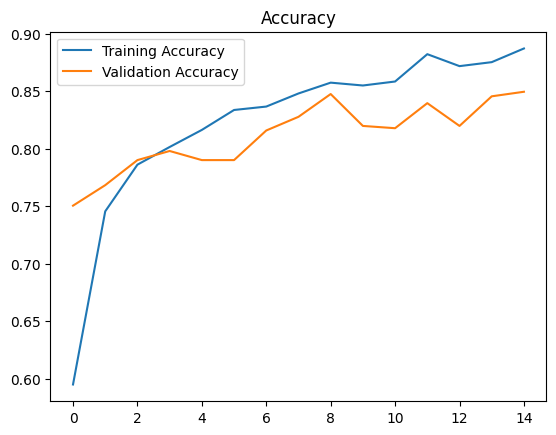

In [18]:
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Accuracy")
plt.show()

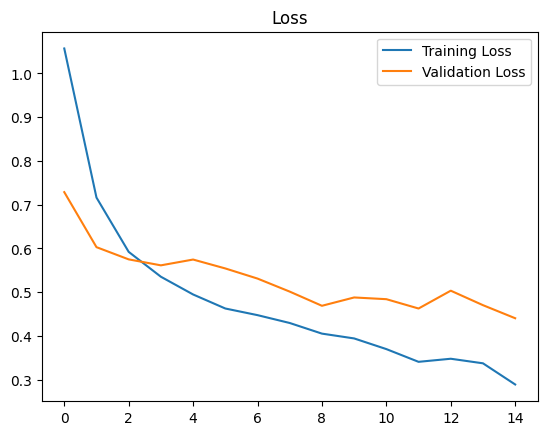

In [19]:
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.legend()
plt.title("Loss")
plt.show()

In [1]:
model.save("../model/waste_classifier.bestVersion")

NameError: name 'model' is not defined